# Setup

In [1]:
# # Summary
# 
# Lets fit the models to the actual data.

# ---
# # Setup

# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from skopt.space import Real
from skopt.utils import use_named_args
from skopt.plots import plot_convergence, plot_objective, plot_evaluations



from popy.simulation_tools import *
from popy.io_tools import load_behavior, load_behavior_yuri
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll, fit_simulate


# data loading

def get_data_custom(monkey):
    if monkey in ['ka', 'po']:
        behav_monkey = load_behavior(monkey)
        behav_monkey = drop_time_fields(behav_monkey)
    elif monkey in ['yu_sham', 'yu_DCZ']:
        behav_monkey = load_behavior_yuri()
        behav_monkey = behav_monkey.loc[behav_monkey['monkey'] == monkey]
    else:
        raise ValueError(f'Unknown monkey: {monkey}')
    
    behav_monkey = add_switch_info(behav_monkey)
    behav_monkey = convert_column_format(behav_monkey, original='behavior')

    behav_monkey = behav_monkey.dropna()

    return behav_monkey




# Init

In [2]:

make_plots = False

monkey = 'po'


behav_monkey = get_data_custom(monkey)
#behav_monkey = pd.read_pickle('results/behavior_strategic_reset.pkl')

behav_monkey

# ## Create environment

# Create the environment
env = gym.make("zsombi/monkey-bandit-task-v0", n_arms=3, max_episode_steps=100_000)

# Set container (to collect pandas series into a dataframe)
results = {}
behaviors_simulated = {f'MONKEY {monkey.upper()}': behav_monkey}




# Simulate models

## Simple RL

In [ ]:

# ## 1. RL

# ### Simple RL agent

# Define parameter space for ShiftValueAgent
agent_class = QLearner
model_name = 'Q-Learner'

param_space = [
    Real(0.3, .8, name='alpha'),
    Real(2, 20.0, name='beta'),
]

fixed_params = {
    'structure_aware': False
}

res_temp, behavior_temp = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, CV_splits=3, make_plots=make_plots, n_calls=150, n_initial_points=100)
results[model_name] = res_temp
behaviors_simulated[model_name] = behavior_temp



## Inferential RL

- best fit paras : alpha = 0.127, beta = 8.729 
- best performance params : alpha = 0.1301733966408454, beta = 66.81579533811015
- candidate model params : alpha = 0.127, beta = 80


In [ ]:

# Define parameter space for ShiftValueAgent
agent_class = QLearner
model_name = 'Q-Learner'

param_space = [
    Real(0.01, .8, name='alpha'),
    Real(2, 20.0, name='beta'),
]

fixed_params = {
    'structure_aware': True
}

res_temp, behavior_temp = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, CV_splits=3, make_plots=make_plots, n_calls=150, n_initial_points=100)

print(f"Best parameters: alpha= {res_temp['alpha']:.2f}, beta= {res_temp['beta']:.2f}")



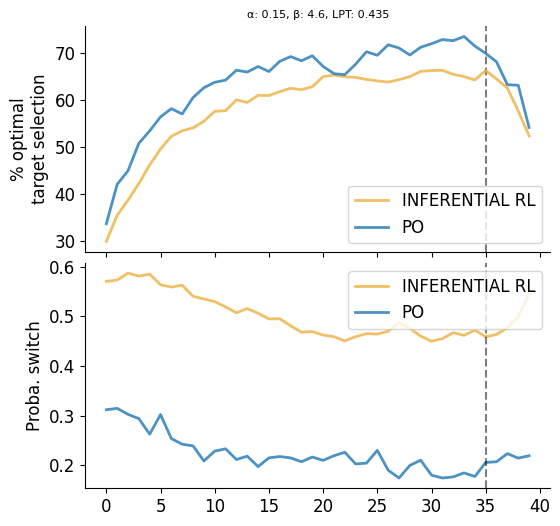

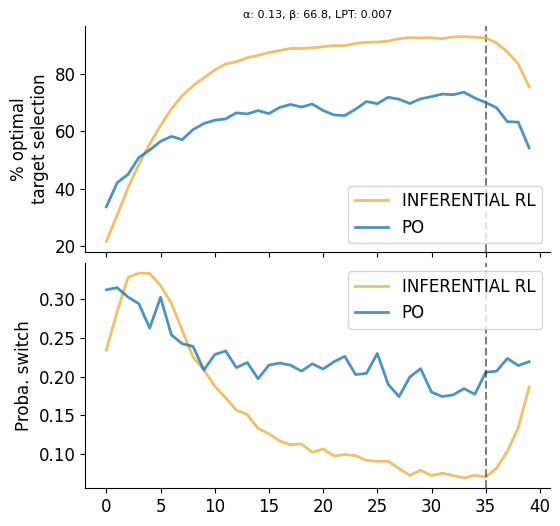

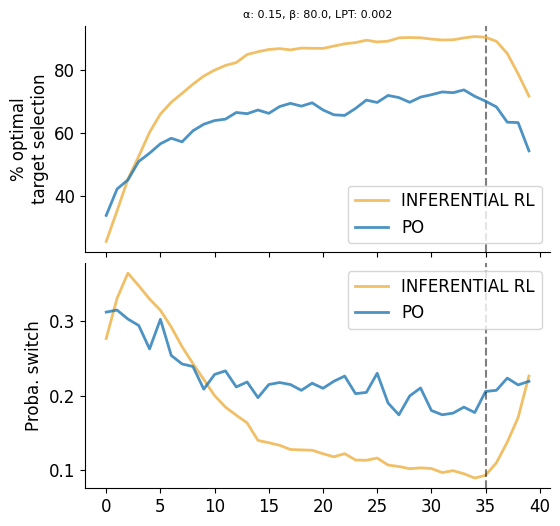

In [3]:
# param grid of alpha from 0.1 to 1, beta from 1 to 100

agent_class = QLearner
model_name = 'Inferential RL'

param_grid = [
    {'alpha': 0.14989319361701048, 'beta': 4.613720171756842},
    {'alpha': 0.1301733966408454, 'beta': 66.81579533811015},
    {'alpha': 0.14989319361701048, 'beta': 80}
]

fixed_params = {
    'structure_aware': True
}

behav_monkey = behav_monkey.copy()
behav_monkey['monkey'] = monkey.upper()
behav_monkey['model'] = 'recording'

behavs_all = []
for params in param_grid:
    behavior_simulated = simulate_agent(
            agent_class=agent_class, 
            params=params,
            env=env,
            fixed_params=fixed_params
        )
    
    reward_rate = behavior_simulated['reward'].mean()
    proba_best = (behavior_simulated['action'] == behavior_simulated['best_arm']).mean()

    ll = estimate_ll(agent_class=agent_class,
                     params=params,
                     behavior_original=behav_monkey,
                     fixed_params=fixed_params)
    LPT = np.exp(ll / len(behav_monkey))


    behavior_simulated['monkey'] = 'Inferential RL'
    behavior_simulated['model'] = 'Inferential RL'
    behavior_simulated['session'] = 0

    # merge with original behavior

    behavior_simulated = pd.concat([behavior_simulated, behav_monkey], ignore_index=True)

    behavior_simulated = convert_column_format(behavior_simulated, original='simulation')
    
    fig, axs = plot_strategy(behavior_simulated, paper_format=False, verbose=False)
    axs[0].set_title(f'α: {params["alpha"]:.2f}, β: {params["beta"]:.1f}, LPT: {LPT:.3f}', fontsize=8)
    # remove legend and xlabel from the second plot
    #axs[1].get_legend().remove()
    axs[1].set_xlabel('')
    


In [4]:
behav_monkey = behav_monkey.copy()
behav_monkey['monkey'] = monkey.upper()
behav_monkey['model'] = 'recording'

behavior_temp['monkey'] = 'Inferential RL'
behavior_temp['model'] = 'Inferential RL'
behavior_temp['session'] = 0

# merge with original behavior

behavior_simulated = pd.concat([behavior_temp, behav_monkey], ignore_index=True)

behavior_simulated = convert_column_format(behavior_simulated, original='simulation')

fig, axs = plot_strategy(behavior_simulated, paper_format=True, verbose=False)
axs[0].set_title(f'α: {res_temp["alpha"]:.2f}, β: {res_temp["beta"]:.1f}, LPT: {res_temp["LPT_CV"]:.3f}', fontsize=8)
axs[1].legend().remove()
plt.tight_layout()

NameError: name 'behavior_temp' is not defined

In [5]:
behav_monkey = behav_monkey.copy()
behav_monkey['monkey'] = monkey.upper()
behav_monkey['model'] = 'recording'

behavior_temp['monkey'] = 'Inferential RL'
behavior_temp['model'] = 'Inferential RL'
behavior_temp['session'] = 0

# merge with original behavior

behavior_simulated = pd.concat([behavior_temp, behav_monkey], ignore_index=True)

behavior_simulated = convert_column_format(behavior_simulated, original='simulation')

fig, axs = plot_strategy(behavior_simulated, paper_format=True, verbose=False)
axs[0].set_title(f'α: {res_temp["alpha"]:.2f}, β: {res_temp["beta"]:.1f}, LPT: {res_temp["LPT_CV"]:.3f}', fontsize=8)
axs[1].legend().remove()
plt.tight_layout()

NameError: name 'behavior_temp' is not defined

In [12]:
# param grid of alpha from 0.1 to 1, beta from 1 to 100

agent_class = QLearner
model_name = 'Inferential RL'

param_grid = {
    'alpha': np.linspace(0.1, .30, 5),
    'beta': np.linspace(5, 20, 5)
}

fixed_params = {
    'structure_aware': True
}


behavs_all = []
for alpha, beta in itertools.product(param_grid['alpha'], param_grid['beta']):
    params = {'alpha': alpha, 'beta': beta}    
    
    behavior_simulated = simulate_agent(
            agent_class=agent_class, 
            params=params,
            env=env,
            fixed_params=fixed_params
        )
    
    reward_rate = behavior_simulated['reward'].mean()
    proba_best = (behavior_simulated['action'] == behavior_simulated['best_arm']).mean()

    ll = estimate_ll(agent_class=agent_class,
                     params=params,
                     behavior_original=behav_monkey,
                     fixed_params=fixed_params)
    LPT = np.exp(ll / len(behav_monkey))


    behavs_all.append({
        'alpha': alpha,
        'beta': beta,
        'reward_rate': reward_rate,
        'proba_best': proba_best,
        'behavior': behavior_simulated,
        'LPT': LPT
    })

    print(f'Reward rate: {reward_rate}, Proba best: {proba_best}, LPT: {LPT:3f}')


Reward rate: 0.49096, Proba best: 0.57612, LPT: 0.430032
Reward rate: 0.53338, Proba best: 0.6851, LPT: 0.398230
Reward rate: 0.55129, Proba best: 0.73577, LPT: 0.334954
Reward rate: 0.56284, Proba best: 0.76403, LPT: 0.270407
Reward rate: 0.56944, Proba best: 0.77742, LPT: 0.214137
Reward rate: 0.50667, Proba best: 0.60583, LPT: 0.434850
Reward rate: 0.54262, Proba best: 0.70145, LPT: 0.389851
Reward rate: 0.55995, Proba best: 0.74673, LPT: 0.318757
Reward rate: 0.56826, Proba best: 0.76436, LPT: 0.251306
Reward rate: 0.57051, Proba best: 0.77347, LPT: 0.194845
Reward rate: 0.50861, Proba best: 0.60748, LPT: 0.429762
Reward rate: 0.54212, Proba best: 0.69063, LPT: 0.372696
Reward rate: 0.55621, Proba best: 0.72683, LPT: 0.296447
Reward rate: 0.5584, Proba best: 0.73782, LPT: 0.228171
Reward rate: 0.56442, Proba best: 0.74905, LPT: 0.172998
Reward rate: 0.51103, Proba best: 0.60711, LPT: 0.419230
Reward rate: 0.53761, Proba best: 0.6752, LPT: 0.350201
Reward rate: 0.54552, Proba best: 

In [13]:
# print best params and LPT
best_params = {'LPT': 0}
for behav in behavs_all:
    if behav['LPT'] > best_params['LPT']:
        best_params = behav

print(f"Best params: alpha = {best_params['alpha']:.3f}, beta = {best_params['beta']:.3f}, LPT = {best_params['LPT']:.3f}")

Best params: alpha = 0.150, beta = 5.000, LPT = 0.435


/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_24758/4134838191.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


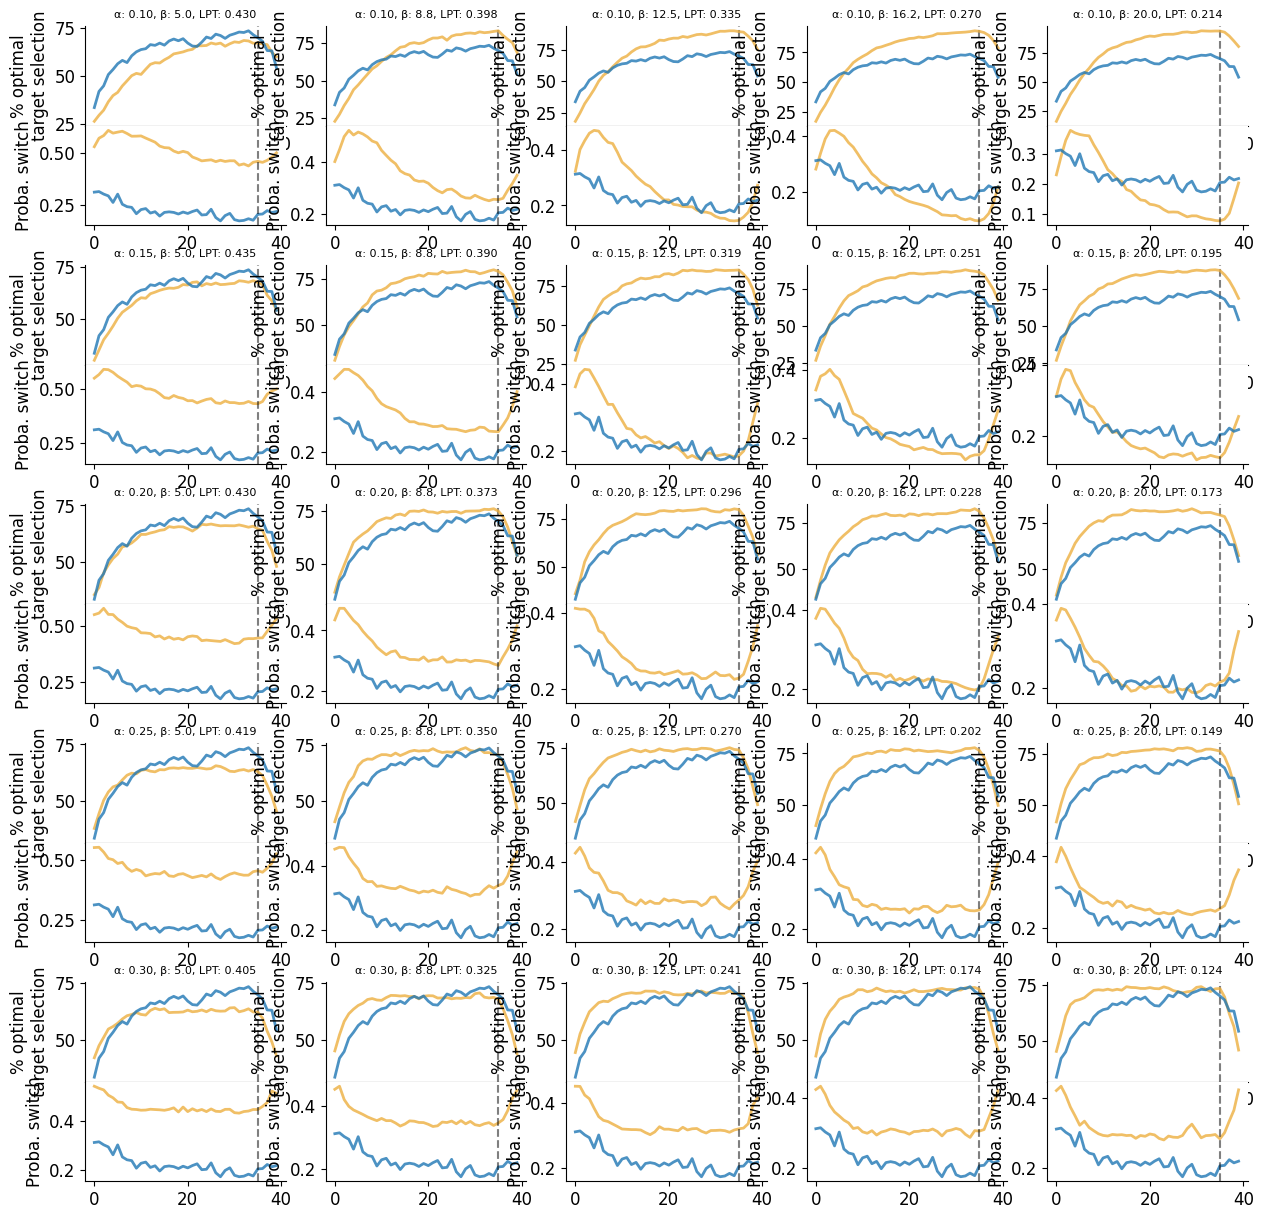

In [14]:
# plot in a grid
n_rows = param_grid['alpha'].shape[0]
n_cols = param_grid['beta'].shape[0]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), sharex=True, sharey=True)

behav_monkey = behav_monkey.copy()
behav_monkey['monkey'] = monkey.upper()
behav_monkey['model'] = 'recording'

for i, (alpha, beta) in enumerate(itertools.product(param_grid['alpha'], param_grid['beta'])):
    ax = axes[i // n_cols, i % n_cols]
    behavior_simulated = [b['behavior'] for b in behavs_all if b['alpha'] == alpha and b['beta'] == beta][0]
    behavior_simulated['monkey'] = 'Inferential RL'
    behavior_simulated['model'] = 'Inferential RL'
    behavior_simulated['session'] = 0

    lpt = [b['LPT'] for b in behavs_all if b['alpha'] == alpha and b['beta'] == beta][0]

    # merge with original behavior

    behavior_simulated = pd.concat([behavior_simulated, behav_monkey], ignore_index=True)

    behavior_simulated = convert_column_format(behavior_simulated, original='simulation')
    
    fig, axs = plot_strategy(behavior_simulated, ax=ax, paper_format=True, verbose=False)
    axs[0].set_title(f'α: {alpha:.2f}, β: {beta:.1f}, LPT: {lpt:.3f}', fontsize=8)
    # remove legend and xlabel from the second plot
    axs[1].get_legend().remove()
    axs[1].set_xlabel('')

plt.tight_layout()

## Multiple learning rates

In [ ]:
# ### Multiple learning rates

'''# Define parameter space for ShiftValueAgent
agent_class = QLearner
model_name = 'Q-Learner multiple alphas'

param_space = [
    Real(0.01, .6, name='alpha'),
    Real(0.01, .3, name='alpha_unchosen'),
    Real(3, 20.0, name='beta'),
]

fixed_params = {
    'structure_aware': True
}

res_temp, behav_q_learn_multiple = fit_simulate(agent_class, param_space, env, behav_monkey, fixed_params, 
                                                model_name, make_plots=True,  verbose=False,
                                            n_calls=150, n_initial_points=100)
results_list.append(res_temp)
behaviors_simulated[model_name] = behav_q_learn_multiple'''


In [ ]:
'''
# save fitting results

res_all = pd.DataFrame.from_dict(results, orient='index').reset_index()
res_all = res_all.rename(columns={'index': 'Model'})

# reorder columns: [Model, epsilon, alpha, beta, V0, etc]
columns = res_all.columns
new_columns = ['Model', 'epsilon', 'alpha', 'beta', 'V0'] + [col for col in columns if col not in ['Model', 'epsilon', 'alpha', 'beta', 'V0']]
res_all = res_all[new_columns]

# remove Model=Q-Learner multiple alphas
#res_all = res_all.loc[res_all['Model'].isin(['WSLS agent (long history)', 'Q-Learner', 'Q-Learner counterfactual', 'Shift-value agent with reset'])]

# save results
from popy.config import PROJECT_PATH_LOCAL
floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}.csv')
res_all.to_csv(floc)
print(f'Saved results to {floc}')

# save behaviors

behavs = []
bahv_monkey = behaviors_simulated[f'MONKEY {monkey.upper()}']
behav_monkey = bahv_monkey.drop(columns=['switch'])
behav_monkey['model'] = 'recording'
behavs.append(behav_monkey)

for key, behav_temo in behaviors_simulated.items():
    if key != f'MONKEY {monkey.upper()}':
        behav_temo['monkey'] = monkey
        behav_temo['session'] = 0
        behav_temo['model'] = key
        behavs.append(behav_temo)

behaviors_simulated_all = pd.concat(behavs, axis=0)
cols = ['monkey', 'model', 'session'] + [col for col in behav_monkey.columns if col not in ['monkey', 'session', 'model']]
behaviors_simulated_all = behaviors_simulated_all[cols]

# reset index
behaviors_simulated_all = behaviors_simulated_all.reset_index(drop=True)

# save
from popy.config import PROJECT_PATH_LOCAL
floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_behaviors_{monkey}.pkl')
behaviors_simulated_all.to_pickle(floc)
print(f'Behaviors saved to {floc}')'''